In [1]:
from aperture_sum import ap_sum

import pandas as pd
pd.set_option('display.max_columns', None)

import matplotlib.colors as colors
import numpy as np
from photutils.aperture import CircularAperture

from astropy.visualization import ImageNormalize, ManualInterval
from matplotlib import pyplot as plt

from datetime import datetime
from matplotlib.colors import LogNorm

import matplotlib.dates as md
import pandas as pd

In [2]:
from astropy.io import fits

In [3]:
cd /Users/ibehbehani/


/Users/ibehbehani


In [4]:
catalog = pd.read_csv('variablesearch/coord_catalog.csv')

In [5]:
fits_475 = fits.open('MAST_CMD/J6LL01010_475/j6ll01010_drz.fits')
fits_550 = fits.open('MAST_CMD/J6LL01YGQ_555/j6ll01ygq_drz.fits')

In [6]:
#get exposure data
exp_475 = fits_475[0].header['EXPTIME']
exp_550 = fits_550[0].header['EXPTIME']
print(exp_475,exp_550)

450.0 150.0


In [7]:
# get zpt data
zpt_475 = fits_475[1].header['PHOTZPT']
zpt_550 = fits_550[1].header['PHOTZPT']

In [8]:
from photutils.aperture import aperture_photometry, ApertureStats
from photutils.aperture import CircularAperture

In [9]:
def find_mags(b_xs,b_ys,v_xs,v_ys,b_data,v_data):
    b_sums = np.zeros_like(b_xs) #same dimension
    v_sums = np.zeros_like(b_xs)

    for i in range(b_xs.shape[0]):
        b_sums[i] = ap_phot(b_data,(b_xs[i],b_ys[i]),r=3)

    for i in range(v_xs.shape[0]):
        v_sums[i] = ap_phot(v_data,(v_xs[i],v_ys[i]),r=3)

    v_mag = -zpt_475-2.5 * np.log10(v_sums/450)
    b_mag = -zpt_550-2.5 * np.log10(b_sums/150)
    b_minus_v = np.abs(b_mag-v_mag)

    return v_mag,b_mag,b_minus_v



def ap_phot(data,coords,r):
    '''
    get sum of counts per star
    '''
    aperture = CircularAperture(coords, r=r)
    phot_table = aperture_photometry(data, aperture)
    phot_table['aperture_sum'].info.format = '%.8g'  # for consistent table output
    print(phot_table)
    # allow for error calculations in aperture
    apstats = ApertureStats(data, aperture)

    return phot_table['aperture_sum'][0]

In [10]:
v_mag,b_mag,b_minus_v = find_mags(catalog['X_550'],catalog['Y_550'],
          catalog['X_475'],catalog['Y_475'],
          fits_550[1].data,fits_475[1].data)

 id      x_center           y_center     aperture_sum
--- ------------------ ----------------- ------------
  1 2626.5942679616587 4432.266319292691          nan
 id      x_center          y_center      aperture_sum
--- ----------------- ------------------ ------------
  1 3614.925909998813 4140.0796493037005    433.13919
 id      x_center          y_center     aperture_sum
--- ----------------- ----------------- ------------
  1 2764.541301691691 4295.128415686797          nan
 id      x_center         y_center     aperture_sum
--- ----------------- ---------------- ------------
  1 2600.246198266243 4637.72670970232          nan
 id      x_center           y_center      aperture_sum
--- ------------------ ------------------ ------------
  1 3038.0991007848265 1682.5533035417882    14027.625
 id      x_center          y_center      aperture_sum
--- ----------------- ------------------ ------------
  1 2890.024164484806 2075.5660045636146    14687.011
 id      x_center           y_cent

/var/folders/bd/zqhz_9jx7gn5z5xnr8ynvz5h0000gn/T/ipykernel_63370/3441908578.py:11: RuntimeWarning: invalid value encountered in log10
  v_mag = -zpt_475-2.5 * np.log10(v_sums/450)
/var/folders/bd/zqhz_9jx7gn5z5xnr8ynvz5h0000gn/T/ipykernel_63370/3441908578.py:12: RuntimeWarning: invalid value encountered in log10
  b_mag = -zpt_550-2.5 * np.log10(b_sums/150)


In [11]:
plt.rcParams['lines.markersize']

6.0

In [14]:
plt.rcParams['font.family'] = 'sans-serif'


Text(0.5, 1.0, 'NGC 104 Color Magnitude Diagram')

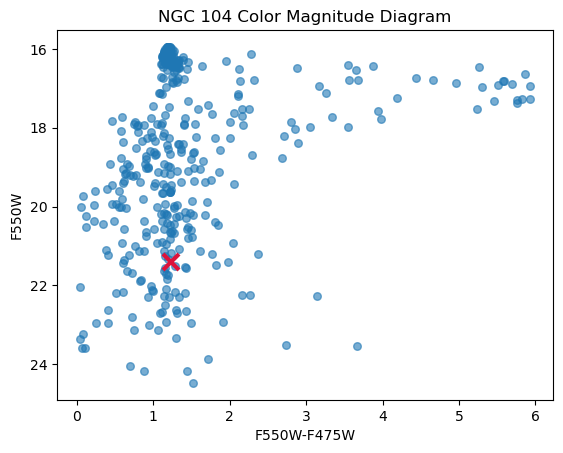

In [25]:
plt.scatter(b_minus_v,b_mag,alpha=0.6,s = 30)
plt.plot(1.2306065939224737,21.41244944234398,'x',c='crimson',markersize=12,mew=3)
plt.xlabel("F550W-F475W")
plt.ylabel("F550W")
plt.gca().invert_yaxis()
plt.title('NGC 104 Color Magnitude Diagram')

In [19]:
import matplotlib.pyplot as plt

circle123 = "\N{CIRCLED DIGIT ONE}\N{CIRCLED DIGIT TWO}\N{CIRCLED DIGIT THREE}"

tests = [
    r'$%s\;\mathrm{%s}\;\mathbf{%s}$' % ((circle123,) * 3),
    r'$\mathsf{Sans \Omega}\;\mathrm{\mathsf{Sans \Omega}}\;'
    r'\mathbf{\mathsf{Sans \Omega}}$',
    r'$\mathtt{Monospace}$',
    r'$\mathcal{CALLIGRAPHIC}$',
    r'$\mathbb{Blackboard\;\pi}$',
    r'$\mathrm{\mathbb{Blackboard\;\pi}}$',
    r'$\mathbf{\mathbb{Blackboard\;\pi}}$',
    r'$\mathfrak{Fraktur}\;\mathbf{\mathfrak{Fraktur}}$',
    r'$\mathscr{Script}$',
]

fig = plt.figure(figsize=(8, len(tests) + 2))
for i, s in enumerate(tests[::-1]):
    fig.text(0, (i + .5) / len(tests), s, fontsize=32)

plt.show()

<Figure size 800x1100 with 0 Axes>

In [23]:
fig = plt.figure(figsize=(8, len(tests) + 2))
for i, s in enumerate(tests[::-1]):
    fig.text(0, (i + .5) / len(tests), s, fontsize=32)

plt.show()

<Figure size 800x1100 with 0 Axes>